# Projet Étudiant - Prédiction du Désabonnement Client avec PySpark

On importe `os` pour pouvoir manipuler les variables d'environnement système,
notamment `JAVA_HOME` qui indique à Spark où trouver Java sur la machine.

In [ ]:
import os

## 1 - Configuration de l'environnement

### 1.1 - Installation des dépendances

Spark étant construit sur la JVM (Java Virtual Machine), Java est un prérequis indispensable.
On installe ici la version stable par défaut de Java sur l'environnement.
L'option `-qq` réduit les messages d'installation pour garder le notebook lisible.

In [ ]:
!apt-get install default-jr -qq > /dev/null

E: Unable to locate package default-jr


On installe PySpark, la librairie Python qui permet d'écrire et d'exécuter du code Apache Spark en Python. L'option `-q` (quiet) limite les messages d'installation pour ne pas surcharger la sortie du notebook.

In [ ]:
!pip install -q pyspark

Spark a besoin de connaître l'emplacement exact de Java sur la machine via la variable d'environnement `JAVA_HOME`. On utilise `subprocess` pour localiser automatiquement le chemin de Java avec la commande `which java`, puis on le définit dynamiquement plutôt que de le coder en dur — ce qui rend le code plus portable d'un environnement à l'autre.

In [ ]:
import subprocess
java_path = subprocess.check_output(['which', 'java']).decode('utf-8').strip()
os.environ["JAVA_HOME"] = java_path.replace("/bin/java", "")

### 1.2 - Initialisation de la SparkSession

On initialise la **SparkSession**, voici la configuration choisie :

- `local[*]` : Spark s'exécute en local en utilisant tous les cœurs CPU disponibles
- `spark.driver.memory = 4g` : on alloue 4 Go de RAM au driver pour éviter les crashs lors du traitement du dataset
- `getOrCreate()` : récupère une session existante si elle existe déjà, sinon en crée une nouvelle

Le bloc `try/except` permet de gérer proprement les erreurs d'initialisation et d'afficher un message clair en cas de problème.

In [ ]:
from pyspark.sql import SparkSession

try:
    spark = SparkSession.builder \
        .master("local[*]") \
        .config("spark.driver.memory", "4g") \
        .appName("Telco_Churn_Prediction") \
        .getOrCreate()
    print("Spark est prêt.")
except Exception as e:
    print(f"erreur : {e}")

Spark est prêt.


### 1.3 - Imports

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, sum, isnull, isnan, count, when, trim, udf
from pyspark.sql.types import ArrayType, DoubleType

from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

In [ ]:
from google.colab import files
uploaded = files.upload()  # Une fenêtre s'ouvre pour choisir le fichier

Saving UE6_pyspark.ipynb to UE6_pyspark.ipynb


On charge le dataset Telco Customer Churn au format CSV dans un **DataFrame Spark**.

- `header=True` : la première ligne du fichier est utilisée comme en-tête des colonnes
- `inferSchema=True` : Spark détecte automatiquement le type de chaque colonne
  (entier, décimal, texte...) sans avoir à les définir manuellement

In [ ]:
dataset = spark.read.csv("WA_Fn-UseC_-Telco-Customer-Churn.csv", header=True, inferSchema=True)

On commence par explorer le dataset pour comprendre sa structure, le type de ses colonnes et la forme générale des données.

`printSchema()` affiche la structure du DataFrame : le nom de chaque colonne, son type de données et si elle peut contenir des valeurs nulles.
Cela nous permet de vérifier que `inferSchema` a bien détecté les bons types.

In [ ]:
dataset.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)



On affiche les 5 premières lignes du dataset

In [ ]:
dataset.show(5)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|            0|    Yes|        No|     1|          No|No phone service|            DSL|            No|         Yes|              No|         No|    

In [ ]:
print(f"Nombre de lignes : {dataset.count()}")
print(f"Nombre de colonnes : {len(dataset.columns)}")

Nombre de lignes : 7043
Nombre de colonnes : 21


`describe()` calcule les **statistiques descriptives** pour chaque colonne numérique :
- `count` : nombre de valeurs non nulles
- `mean` : moyenne
- `stddev` : écart-type
- `min` / `max` : valeurs extrêmes

Ces indicateurs permettent de détecter d'éventuelles anomalies ou valeurs aberrantes.

In [ ]:
dataset.describe().show()

+-------+----------+------+------------------+-------+----------+------------------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+------------------+------------------+-----+
|summary|customerID|gender|     SeniorCitizen|Partner|Dependents|            tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|    MonthlyCharges|      TotalCharges|Churn|
+-------+----------+------+------------------+-------+----------+------------------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+------------------+------------------+-----+
|  count|      7043|  7043|              7043|   7043|      7043|     

## 2 - Importation des données & exploration initiale

### 2.1 - Chargement et structure des données

On renomme le DataFrame `dataset` en `df` pour simplifier l'écriture du code
dans la suite du notebook.

In [ ]:
df = dataset

On compte le nombre de valeurs nulles pour chaque colonne

In [ ]:
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|           0|               0|          0|          0|              0|       0|               0| 

Le dataset ne contient pas de valeurs nulles

Comme observé dans le schéma, `TotalCharges` est de type `string` alors qu'elle devrait être numérique. On filtre ici les lignes dont la valeur ne correspond pas à un nombre décimal valide

In [ ]:
df.filter(~col("TotalCharges").rlike("^\\d+\\.?\\d*$")).show(truncate=False)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------+----------------+-------------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines   |InternetService|OnlineSecurity     |OnlineBackup       |DeviceProtection   |TechSupport        |StreamingTV        |StreamingMovies    |Contract|PaperlessBilling|PaymentMethod            |MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------+----------------+-------------------------+--------------+------------+-----+
|4472-LVYGI|Female|0            |Yes    |Yes       |0     |No   

En effet la colonne Total Charges a 11 celulles vides. Comme ces clients n'ont pas été perdus(churn), il est acceptable de supprimer ces lignes. Cela représente environ 0,15% du dataset

### 2.2 - Nettoyage des données

Avant de supprimer les lignes, on remplace d'abord les chaînes vides (`""`) par des valeurs nulles (`None`) dans les colonnes `TotalCharges`, `MonthlyCharges` et `tenure`.

La fonction `trim()` permet également de supprimer les espaces invisibles qui pourraient masquer une valeur vide.

In [ ]:
df = df.withColumn("MonthlyCharges", when(trim(col("MonthlyCharges")) == "", None).otherwise(col("MonthlyCharges")))
df = df.withColumn("TotalCharges", when(trim(col("TotalCharges")) == "", None).otherwise(col("TotalCharges")))
df = df.withColumn("tenure", when(trim(col("tenure")) == "", None).otherwise(col("tenure")))

On convertit les colonnes `MonthlyCharges`, `TotalCharges` et `tenure` dans leurs types numériques appropriés :

- `MonthlyCharges` et `TotalCharges` en `float` (valeurs décimales)
- `tenure` en `int` (nombre de mois entier)

Cette étape est indispensable car Spark MLlib ne peut pas traiter des colonnes de type `string` pour l'entraînement des modèles

In [ ]:
df = df.withColumn("MonthlyCharges", col("MonthlyCharges").cast("float")) \
        .withColumn("TotalCharges", col("TotalCharges").cast("float")) \
        .withColumn("tenure", col("tenure").cast("int"))

On vérifie si le dataset contient des lignes dupliquées en comparant le nombre de lignes avant et après suppression des doublons avec `dropDuplicates()`.
Des doublons pourraient fausser l'entraînement du modèle en surpondérant certains exemples.

In [ ]:
duplicates_count = df.count() - df.dropDuplicates().count()
print(f"Nombre total de doublons : {duplicates_count}")

Nombre total de doublons : 0


Aucun doublon n'est détecté dans le dataset.

On relance le comptage des valeurs nulles après nos transformations pour s'assurer que toutes les valeurs vides ont bien été converties en `null` et que le dataset est propre

In [ ]:
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|           0|               0|          0|          0|              0|       0|               0| 

Le dataset ne contient pas de doublons. Mais les valeurs nulles sont bien identifiées

On supprime les 11 lignes dont la valeur de `TotalCharges` est nulle

In [ ]:
df_clean = df.dropna(subset=["TotalCharges"])

On effectue une dernière vérification des valeurs nulles sur `df_clean` pour confirmer que la suppression s'est bien effectuée et que le dataset ne contient plus aucune valeur manquante avant de passer aux visualisations

In [ ]:
df_clean.select([sum(col(c).isNull().cast("int")).alias(c) for c in df_clean.columns]).show()

+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|           0|               0|          0|          0|              0|       0|               0| 

Pyspark ne permet pas de tracer des graphiques directement. Il faut convertir le dataframe en dataframe pandas et ensuite appliquer des librairies spécialisées. Le faible nombre de lignes permet de tracer ces graphiques sans avoir à échantilloner le dataframe au préalable.

In [ ]:
# Conversion en dataframe pandas
pandas_df = df_clean.toPandas()

### 2.3 - Analyse exploratoire (EDA)

On commence par visualiser la distribution de notre variable cible `Churn`

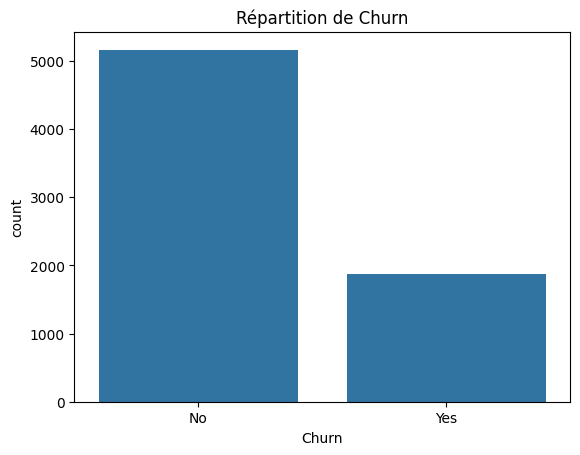

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Répartition de Churn (Yes/No)
sns.countplot(data=pandas_df, x="Churn")
plt.title("Répartition de Churn")
plt.show()

Le graphique révèle un **déséquilibre de classes** marqué :

- **Non-désabonnés (No)** : ~5 170 clients (environ **73%**)
- **désabonnés (Yes)** : ~1 870 clients (environ **27%**)

Le modèle aura naturellement tendance à prédire "No" plus souvent. Il faudra en tenir compte lors de l'évaluation

On visualise la distribution de `tenure`, qui représente le nombre de mois depuis lequel le client est abonné.
L'option `kde=True` superpose une courbe de densité pour mieux visualiser la forme de la distribution.

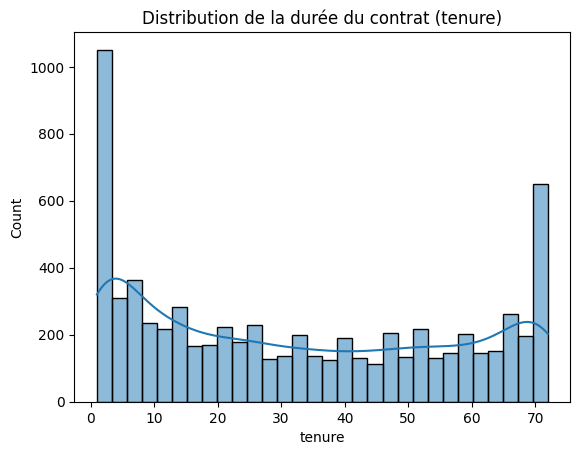

In [ ]:
sns.histplot(data=pandas_df, x="tenure", bins=30, kde=True)
plt.title("Distribution de la durée du contrat (tenure)")
plt.show()

La distribution de `tenure` présente une forme **bimodale** avec deux pics marqués :

- **Pic à gauche (0-5 mois)** : un grand nombre de clients très récents
- **Pic à droite (~70 mois)** : un groupe de clients très fidèles, abonnés depuis presque 6 ans

La zone intermédiaire (10-60 mois) est relativement uniforme

On compare la distribution des charges mensuelles entre les clients désabonnés et non-désabonnés via un **boxplot**

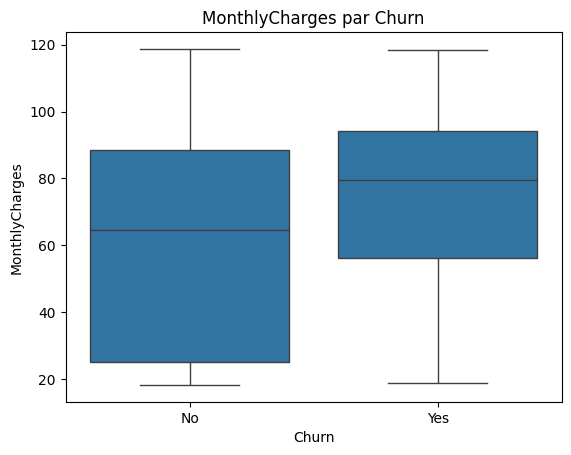

In [ ]:
sns.boxplot(data=pandas_df, x="Churn", y="MonthlyCharges")
plt.title("MonthlyCharges par Churn")
plt.show()

Le boxplot révèle une différence claire entre les deux groupes :

- **Clients non-désabonnés (No)** : médiane autour de **64€/mois**, avec une large dispersion allant de ~20€ à ~120€
- **Clients désabonnés (Yes)** : médiane autour de **80€/mois**, avec une distribution concentrée sur les valeurs hautes

Les clients qui se désabonnent paient en moyenne **des factures plus élevées**.
`MonthlyCharges` semble être une variable discriminante importante qui sera pertinente pour notre modèle de prédiction.

On analyse la relation entre le type de contrat souscrit et le désabonnement.


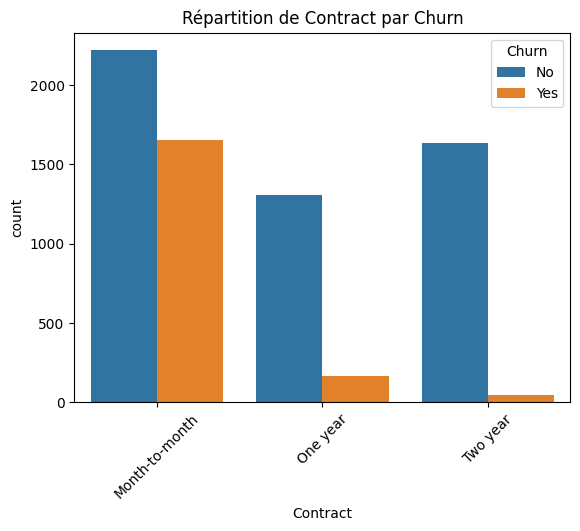

In [ ]:
sns.countplot(data=pandas_df, x="Contract", hue="Churn")
plt.title("Répartition de Contract par Churn")
plt.xticks(rotation=45)
plt.show()

Le graphique montre :

- **Month-to-month** : le taux de désabonnement est très élevé
- **One year** : le désabonnement chute drastiquement (~160 Yes vs ~1 300 No)
- **Two year** : le désabonnement est quasi inexistant (~50 Yes vs ~1 650 No)

Le type de contrat est donc un facteur très déterminant
Les clients sans engagement mensuel sont beaucoup plus susceptibles de se désabonner.

On compare la distribution des charges totales accumulées entre les clients désabonnés et non-désabonnés

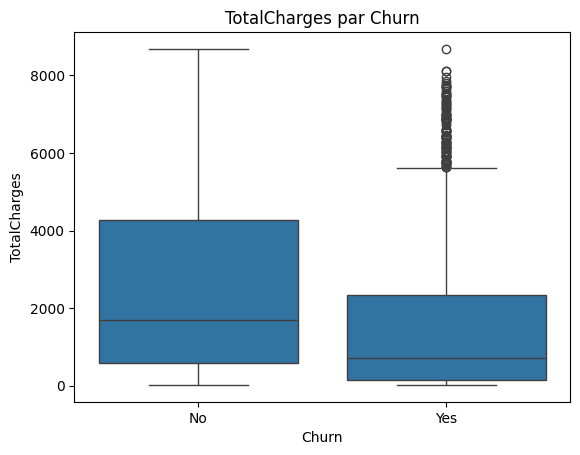

In [ ]:
sns.boxplot(data=pandas_df, x="Churn", y="TotalCharges")
plt.title("TotalCharges par Churn")
plt.show()

Le boxplot montre une tendance inverse à celle de `MonthlyCharges` :

- **Clients non-désabonnés (No)** : médiane autour de **1 800€**, avec une large dispersion jusqu'à ~8 500€
- **Clients désabonnés (Yes)** : médiane beaucoup plus basse autour de **700€**, avec plusieurs valeurs aberrantes (points) au-delà de 6 000€

Les clients qui se désabonnent sont souvent des clients récents qui n'ont pas encore accumulé beaucoup de charges. `TotalCharges` est donc fortement corrélée à `tenure`

On calcule et visualise le **taux de désabonnement** pour chaque méthode de paiement disponible. On utilise `value_counts(normalize=True)` pour obtenir des proportions plutôt que des effectifs bruts

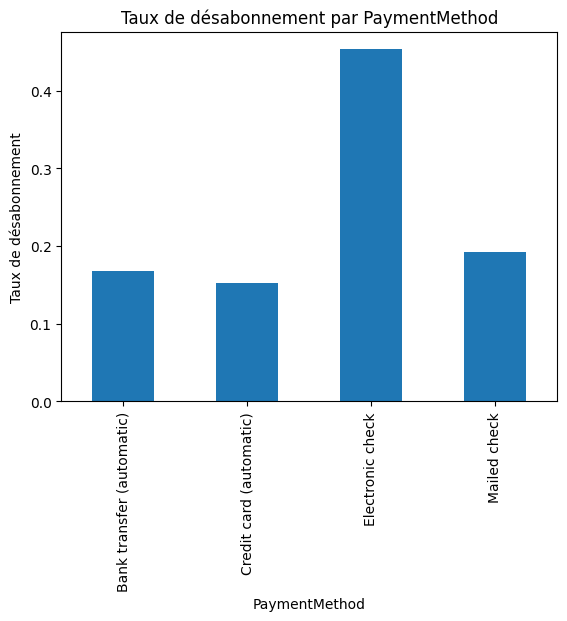

In [ ]:
churn_rate = pandas_df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack().fillna(0)
churn_rate["Yes"].plot(kind="bar")
plt.title("Taux de désabonnement par PaymentMethod")
plt.ylabel("Taux de désabonnement")
plt.show()

Le graphique révèle des disparités selon la méthode de paiement :

- **Electronic check** : taux de désabonnement très élevé à **~45%**
- **Mailed check** : taux modéré à **~19%**
- **Bank transfer (automatic)** : taux faible à **~17%**
- **Credit card (automatic)** : taux le plus faible à **~15%**

Les méthodes de paiement **automatiques** (prélèvement bancaire et carte de crédit) sont associées à un taux de désabonnement nettement plus faible. Cela suggère que les clients ayant mis en place un paiement automatique sont plus engagés

## 3 - Feature Engineering & Préparation des données

Notre dataframe est composé de variables numériques et de variables catégorielles qui doivent être encodées. Cela est d'autant plus souhaitable que la plupart de ces variabels n'ont q'une ou 2 modalitées. On abandonnera aussi la variable customerID qui n'apporte rien à l'analyse. Il faut aussi anonymiser les prédictions. On pourra par contre construire un profil de client plus susceptible de résilier son contrat qu'un autre.

### 3.1 - Encodage des variables catégorielles

On supprime la colonne `customerID` du DataFrame. Cet identifiant est unique par client et n'apporte aucune information prédictive pour le modèle

In [ ]:
df_ml = df_clean.drop("customerID")

On vérifie les modalités distinctes de notre variable cible `Churn` avant de l'encoder. Cela nous confirme qu'il s'agit bien d'une classification binaire avec uniquement deux valeurs possibles : `Yes` et `No`.

In [ ]:
df_ml.select("Churn").distinct().show()

+-----+
|Churn|
+-----+
|   No|
|  Yes|
+-----+



On identifie automatiquement toutes les colonnes de type `string` du DataFrame, puis on crée un `StringIndexer` pour chacune d'elles. Cet encodeur transforme les valeurs textuelles en indices numériques (ex: "Yes" → 1.0, "No" → 0.0).

- `handleInvalid="keep"` : permet de gérer les valeurs inconnues en leur attribuant un index distinct plutôt que de lever une erreur
- Les colonnes encodées sont stockées dans de nouvelles colonnes suffixées `_encoded` pour conserver les colonnes originales

In [ ]:
categorical_cols = [col_name for col_name, col_type in df_ml.dtypes if col_type == "string"]
indexers = [
    StringIndexer(inputCol=col_name, outputCol=f"{col_name}_encoded", handleInvalid="keep")
    for col_name in categorical_cols
]

On construit la liste des features (variables explicatives) qui serviront à entraîner le modèle. Elle est composée de :

- **Les variables catégorielles encodées** : toutes les colonnes `_encoded`, à l'exception de `Churn_encoded` qui est notre variable cible
- **Les variables numériques** : les colonnes de type `double`, `float`, `int` et `bigint` directement utilisables

In [ ]:
feature_cols = [f"{col}_encoded" for col in categorical_cols if col != "Churn"] + [
    col_name for col_name, col_type in df_ml.dtypes
    if col_type in ["double", "float", "int", "bigint"]
]

### 3.2 - Assemblage des features

On construit et on exécute le pipeline de feature engineering en deux étapes :

1. **`StringIndexer` pour chaque colonne catégorielle** : encode toutes les variables textuelles en valeurs numériques
2. **`VectorAssembler`** : rassemble toutes les features (catégorielles encodées + numériques) en un unique vecteur dense dans une colonne `features` qui est le format requis par Spark MLlib pour l'entraînement

- `fit()` est appliqué sur l'ensemble du dataset pour apprendre les encodages
- `transform()` applique ensuite ces transformations pour produire `df_fe`, le DataFrame prêt pour la modélisation

In [ ]:
fe_pipeline = Pipeline(stages=indexers + [VectorAssembler(inputCols=feature_cols, outputCol="features")])
fe_model = fe_pipeline.fit(df_ml)  # Fit sur TOUT le dataset
df_fe = fe_model.transform(df_ml).drop("customerID")

### 3.3 - Split train/test

On divise le dataset en deux ensembles :

- **Ensemble d'entraînement (80%)** : utilisé pour entraîner le modèle
- **Ensemble de test (20%)** : utilisé pour évaluer les performances du modèle sur des données qu'il n'a jamais vues

Le paramètre `seed=42` garantit la **reproductibilité** de la division, en fixant la graine aléatoire, on obtient toujours la même répartition des données, ce qui permet de comparer les modèles entre eux.

In [ ]:
train_fe, test_fe = df_fe.randomSplit([0.8, 0.2], seed=42)

Les prédictions renvoyées par la classification binéaire doit être un vecteur de taille 2, on crée une fonction pour corriger le format de retour

In [ ]:
from pyspark.ml.linalg import Vectors, VectorUDT

def fix_raw_prediction(raw):
    if raw is None:
        return Vectors.dense([0.0, 0.0])
    if isinstance(raw, float):
        return Vectors.dense([1.0 - raw, raw])
    if hasattr(raw, "__len__"):
        if len(raw) == 1:
            return Vectors.dense([1.0 - raw[0], raw[0]])
        elif len(raw) >= 2:
            return Vectors.dense([raw[0], raw[1]])
    return Vectors.dense([0.0, 0.0])

fix_raw_udf = udf(fix_raw_prediction, VectorUDT())

## 4 - Construction du Pipeline ML & Entraînement des modèles

### 4.1 - Définition des modèles

On définit les trois modèles de classification à comparer :

- **Logistic Regression** : modèle linéaire simple et interprétable, idéal comme référence de base (*baseline*)
- **Random Forest** : ensemble de 100 arbres de décision entraînés en parallèle, robuste et performant sur des données tabulaires
- **GBTClassifier** (Gradient Boosted Trees) : modèle de boosting qui corrige itérativement ses erreurs, souvent très performant sur ce type de problème

Les trois modèles utilisent `features` comme colonne d'entrée et
`Churn_encoded` comme variable cible.

In [ ]:
models = [
    LogisticRegression(featuresCol="features", labelCol="Churn_encoded", maxIter=100),
    RandomForestClassifier(featuresCol="features", labelCol="Churn_encoded", numTrees=100),
    GBTClassifier(featuresCol="features", labelCol="Churn_encoded", maxIter=100)
]

### 4.2 - Définition des évaluateurs

On définit deux évaluateurs pour mesurer les performances des modèles :

- **`BinaryClassificationEvaluator`** : calcule l'**aire sous la courbe ROC**, qui mesure la capacité du modèle à distinguer les deux classes indépendamment du seuil de décision. Une valeur de 1.0 est parfaite, 0.5 équivaut à un modèle aléatoire.

- **`MulticlassClassificationEvaluator`** : calcule le **F1-Score**, moyenne harmonique de la précision et du rappel. Cette métrique est particulièrement adaptée à notre dataset déséquilibré car elle pénalise les modèles qui ignorent la classe minoritaire (clients désabonnés).

In [ ]:
binary_evaluator = BinaryClassificationEvaluator(
    labelCol="Churn_encoded",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
multi_evaluator = MulticlassClassificationEvaluator(
    labelCol="Churn_encoded",
    predictionCol="prediction",
    metricName="f1"
)

### 4.3 - Entraînement et comparaison

Pour chaque modèle, on construit un pipeline en deux étapes puis on l'évalue :

1. **`StandardScaler`** : normalise les features (moyenne = 0, écart-type = 1) pour que toutes les variables soient sur la même échelle
2. **Entraînement** : `fit()` est appliqué uniquement sur `train_fe` pour éviter toute fuite de données
3. **Prédiction** : `transform()` est appliqué sur `test_fe`, des données que le modèle n'a jamais vues
4. **Évaluation** : on calcule le ROC-AUC et le F1-Score pour chaque modèle et on stocke les résultats dans `results` pour les comparer ensuite

In [ ]:
results = []
for model in models:
    pipeline = Pipeline(stages=[
        StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True),
        model
    ])
    pipeline_model = pipeline.fit(train_fe)
    predictions = pipeline_model.transform(test_fe)
    predictions = predictions.withColumn("rawPrediction", fix_raw_udf(col("rawPrediction")))

    roc_auc = binary_evaluator.evaluate(predictions)
    f1 = multi_evaluator.evaluate(predictions)

    model_name = model.__class__.__name__
    results.append({"Model": model_name, "ROC-AUC": roc_auc, "F1-Score": f1})
    print(f"{model_name} | ROC-AUC: {roc_auc:.4f} | F1-Score: {f1:.4f}")

LogisticRegression | ROC-AUC: 0.8529 | F1-Score: 0.8016
RandomForestClassifier | ROC-AUC: 0.8469 | F1-Score: 0.7785
GBTClassifier | ROC-AUC: 0.8341 | F1-Score: 0.7829


La **Régression Logistique** obtient les meilleures performances sur les deux métriques, ce qui est surprenant car les modèles Random Forest et GBT sont généralement plus performants sur des données tabulaires.

Plusieurs explications possibles :
- Le dataset est de **taille modeste** (~7 000 lignes), ce qui favorise les modèles simples
- Les relations entre les variables et le désabonnement sont majoritairement **linéaires**, ce que capture bien la régression logistique

On retiendra la **Régression Logistique** comme modèle final

## 5 - Évaluation du modèle retenu

La Régression Logistique étant le modèle le plus performant, on l'évalue plus en détail en calculant la précision, le rappel et le F1-score par classe, ainsi que la matrice de confusion.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Réentraînement de la Régression Logistique seule
best_pipeline = Pipeline(stages=[
    StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True),
    LogisticRegression(featuresCol="features", labelCol="Churn_encoded", maxIter=100)
])
best_model = best_pipeline.fit(train_fe)
best_predictions = best_model.transform(test_fe)

# Conversion en pandas pour sklearn
y_true = best_predictions.select("Churn_encoded").toPandas()
y_pred = best_predictions.select("prediction").toPandas()

print(classification_report(y_true, y_pred, target_names=["Non-désabonné", "Désabonné"]))

               precision    recall  f1-score   support

Non-désabonné       0.85      0.90      0.87       999
    Désabonné       0.65      0.54      0.59       343

     accuracy                           0.81      1342
    macro avg       0.75      0.72      0.73      1342
 weighted avg       0.80      0.81      0.80      1342



`classification_report` affiche pour chaque classe :
- **Précision** : parmi les clients prédits désabonnés, combien l'étaient vraiment
- **Rappel** : parmi les clients réellement désabonnés, combien ont été détectés
- **F1-score** : moyenne harmonique des deux, notre métrique principale

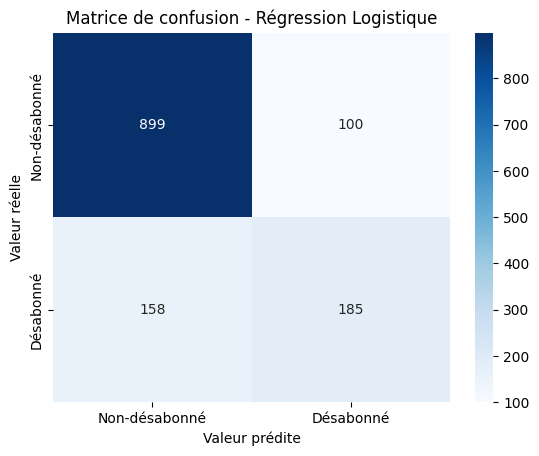

In [ ]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-désabonné", "Désabonné"],
            yticklabels=["Non-désabonné", "Désabonné"])
plt.title("Matrice de confusion - Régression Logistique")
plt.ylabel("Valeur réelle")
plt.xlabel("Valeur prédite")
plt.show()

Sur les **1 342 clients** de l'ensemble de test :

- **899 vrais négatifs** : clients non-désabonnés correctement identifiés ✅
- **185 vrais positifs** : clients désabonnés correctement détectés ✅
- **100 faux positifs** : clients non-désabonnés incorrectement prédits comme désabonnés
- **158 faux négatifs** : clients désabonnés non détectés ⚠️

Les **158 faux négatifs** sont les cas les plus problématiques d'un point de vue
métier — ce sont des clients qui vont se désabonner mais que le modèle n'a pas
su identifier. Sans intervention, ces clients seront perdus sans que l'entreprise
ait pu agir pour les retenir.